### Path

In [1]:
import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'WDBC (J8)'

In [ ]:
import os.path

In [ ]:
# for python script
nb_name = os.path.basename(__file__)[0:-3]
print("Current filename:", nb_name) 

## Import

In [2]:
# Added to silence some warnings.
# from jax.config import config
# config.update("jax_enable_x64", True)

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
# import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
from functools import partial
import time

# from sklearn.datasets import load_breast_cancer
# from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from WDBC_dataset import WDBC_dataset

import numpy as np
import random
import copy
import pickle
import matplotlib.pyplot as plt

from TRAIN_v4_debug_3 import TRAIN

In [3]:
# Noise model
from SQGRU_j8 import SQGRU, qgru

In [4]:
SEED = 0
N_STEPS = 1000000
NUM_SEEDs = 50
BATCH_SIZE = 20

In [5]:
jax.config.update('jax_platform_name', 'cpu') # for cpu

## Model

### QGRU
### Hyper parameters

In [6]:
# model parameters
I_DIM = 1 # input dim
H_DIM = 8 # hidden dim
N_LAY = 3 # number of layers
E_LAY = 1 # enc_layers
E_REUL = 1 # enc_reupload
H_LAY = 1 # hid_layers
H_REUL = 1 # hid_reupload
PO_DIM = -1 # pOut_dim
A_Q_OUT = False # all_qubits_out
PRED_LEN = 1 # pred_length
OUT_TYP = -1 # out_type
ENWE = 2 # enc_n_weights_each
HNWE = 2 # hid_n_weights_each
EVG = None # enc_v_gate
ELVG = None # enc_lay_v_gate
HVG = None # hid_v_gate
HLVG = None # hid_lay_v_gate
G_GATE = 'rx' # gate_gate
L_GATE = ['rx', 'ry'] # lay_gate
N_O_LAY = None # n_out_lay
O_GATE = 'u2' # out_gate
N_HO_LAY = None # n_hout_lay
HO_GATE = 'u2' # hout_gate

# NOISE_MODEL = None
# SHOTS = 1024

In [7]:
# out_fn = None
def out_fn(x):
    return x[:,0]

In [8]:
init_fun, qru_rnn = qgru(I_DIM,H_DIM,N_LAY, enc_layers=E_LAY, enc_reupload=E_REUL,
                                      hid_layers=H_LAY, hid_reupload=H_REUL, all_qubits_out=A_Q_OUT,
                                      pred_length=PRED_LEN, out_type=OUT_TYP, enc_n_weights_each=ENWE,
                                      hid_n_weights_each=HNWE, enc_v_gate=EVG, enc_lay_v_gate=ELVG,
                                      hid_v_gate=HVG, hid_lay_v_gate=HLVG, gate_gate=G_GATE, lay_gate=L_GATE,
                                      n_out_lay=N_O_LAY, out_gate=O_GATE, n_hout_lay=N_HO_LAY, hout_gate=HO_GATE,
                                      out_fun=out_fn)

key = jax.random.PRNGKey(SEED)

## Train

In [9]:
@jax.jit
def loss_fn(params, inputs, targets):
    outputs  = qru_rnn(params, inputs)
    targets_pm = targets * 2 - 1  # 0/1 → -1/+1
    return jnp.mean((outputs - targets_pm) ** 2)

def result_fn(params, dataset):
    inp, tar = zip(*dataset)
    inp     = jnp.array(inp)
    outputs = qru_rnn(params, inp)
    s = 0
    for out, t in zip(outputs, tar):
        pred = 1 if out > 0 else 0
        if pred == int(t):
            s += 1
    return s / len(outputs)

### Dataset

In [10]:
# 加載 WDBC 數據集
WDBC = WDBC_dataset(SEED)
train_dataset, valid_dataset, test_dataset = WDBC.split([341,114,114])
len(train_dataset), len(valid_dataset), len(test_dataset)

(340, 113, 116)

In [12]:


save_name = nb_name + '_dataset_x1_no_noise'
print(save_name)

key, _ = jax.random.split(key)

train = TRAIN(key, init_fun, loss_fn, train_dataset+valid_dataset, test_dataset, result_fn, save_name)
train.N_STEPS = N_STEPS
train.BATCH_SIZE = BATCH_SIZE
train.NUM_SEEDs = 1
train.STD_DEV = 0.0
train.REC_INTE = 10
train.VARI_FRE = 'epoch'
train.ini_learning_rate = 0.01

train.TRAIN_VALID_TEST = jnp.array([len(train_dataset), len(valid_dataset)])
train.ES_THRES = 1e-2
train.ES_LEN = 3
train.ES_MODE = 'loss'
train.ES_DATASET = 'train'

train.train()

# sum_acc += train.acc_results[0][1]
# print('acc:', sum_acc/(i+1))


WDBC (J8)_dataset_x1_no_noise
No previous state recorded.
9, 17: 0.6146248470155247 0.6420041437808206  7.902829885482788 sec       
19, 17: 0.5329772071338027 0.5354672613892433  12.867763996124268 sec       
29, 17: 0.47527728161640975 0.5078176130012088  17.968252420425415 sec       
39, 17: 0.30373066907597784 0.3547107854537558  22.988384008407593 sec       
49, 17: 0.3722209140232402 0.40801691176620425  27.96222734451294 sec        
59, 17: 0.2826041491575154 0.31170134788354187  31.515811443328857 sec       
69, 17: 0.32194551460666865 0.3876810349223062  36.494659423828125 sec       
79, 17: 0.26758849888890374 0.30685953574232067  41.46026420593262 sec       
89, 17: 0.2952926020580938 0.3883357865285238  46.4727897644043 sec          
99, 17: 0.2627713408373417 0.31590727315415296  51.538700580596924 sec       
109, 17: 0.28896079145101705 0.3350993864249049  56.54046320915222 sec        
119, 17: 0.3185776649121572 0.3935670376074855  59.947972536087036 sec        
129, 17:

In [13]:
result_fn(train.vbest_params, test_dataset)

0.9568965517241379

In [ ]:
# ------------------------------ END ----------------------------------------

## Circuit

In [8]:
kk = SQGRU(I_DIM,H_DIM,N_LAY, enc_layers=E_LAY, enc_reupload=E_REUL, hid_layers=H_LAY, hid_reupload=H_REUL, pOut_dim=OUT_TYP,
           enc_n_weights_each=ENWE, hid_n_weights_each=HNWE, enc_v_gate=EVG, enc_lay_v_gate=ELVG,
           hid_v_gate=HVG, hid_lay_v_gate=HLVG, gate_gate=G_GATE, lay_gate=L_GATE,
           n_out_lay=N_O_LAY, out_gate=O_GATE, n_hout_lay=N_HO_LAY, hout_gate=HO_GATE)
kk.num_weights

34

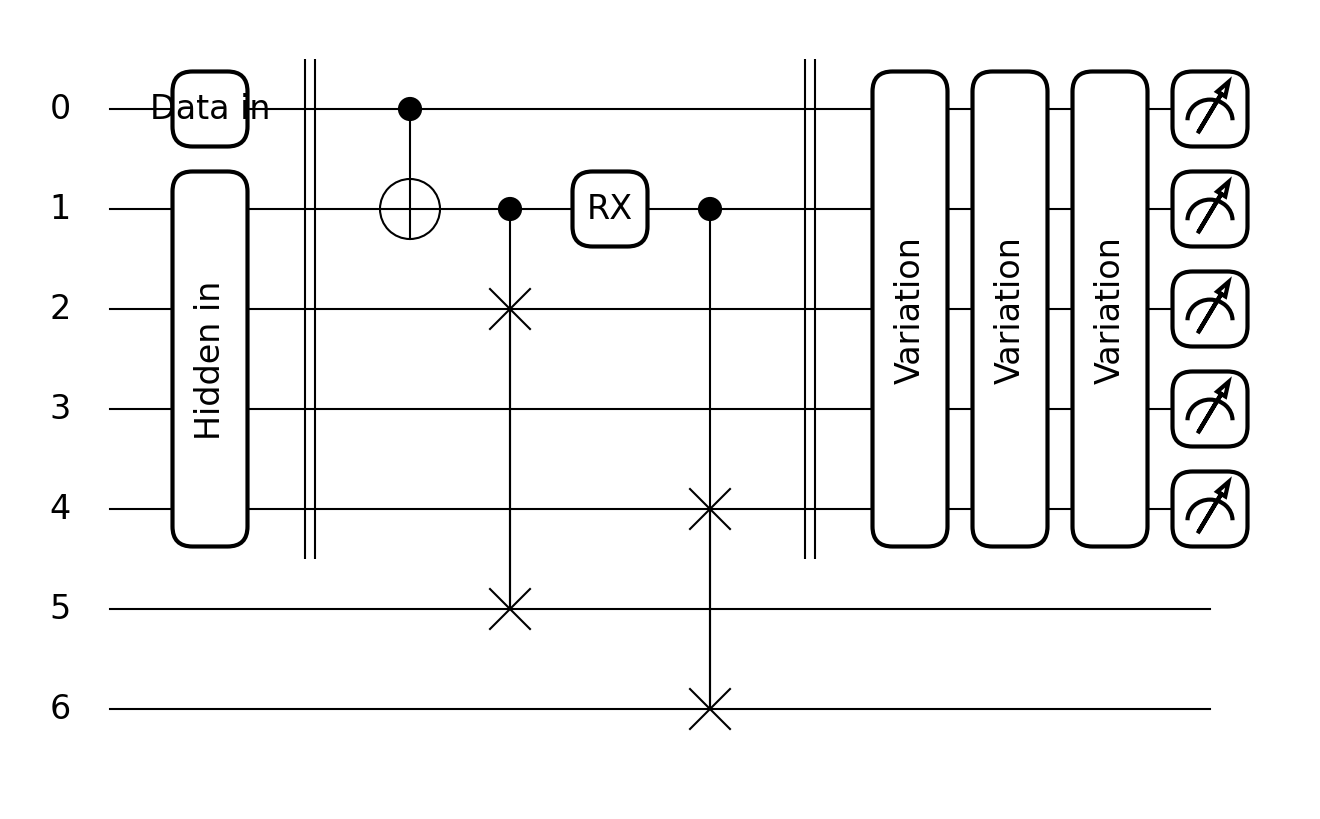

In [10]:
# kk.draw_circuit(level='user')
# kk.draw_circuit(level='device')
kk.draw_circuit()